# Real World Classification

## Load data

Import the necessary libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [2]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [3]:
missing_cols = df.columns[df.isnull().any()]
print("Columns with missing values:", missing_cols)

Columns with missing values: Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'BranchLength'],
      dtype='str')


In [4]:
missing_cols = df.columns[df.isnull().any()]

before_stats = {}

for col in missing_cols:
    before_stats[col] = {
        "median": df[col].median(),
        "std": df[col].std()
    }

print("Columns with missing values before imputation:")
for col in missing_cols:
    print(f"{col}: median = {before_stats[col]['median']:.4f}, std = {before_stats[col]['std']:.4f}")

Columns with missing values before imputation:
SepalLengthCm: median = 6.3000, std = 1.0371
SepalWidthCm: median = 2.9000, std = 0.3896
PetalLengthCm: median = 5.0856, std = 1.5828
PetalWidthCm: median = 1.6000, std = 0.7067
BranchLength: median = 16.3000, std = 1.0352


In [5]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=3)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [6]:
after_stats = {}

for col in missing_cols:
    after_stats[col] = {
        "median": df[col].median(),
        "std": df[col].std()
    }

print("Columns with missing values after KNN imputation:")

for col in missing_cols:
    print(f"{col}: median = {after_stats[col]['median']:.4f}, std = {after_stats[col]['std']:.4f}")

Columns with missing values after KNN imputation:
SepalLengthCm: median = 6.3000, std = 1.0106
SepalWidthCm: median = 2.9000, std = 0.3737
PetalLengthCm: median = 5.0595, std = 1.5791
PetalWidthCm: median = 1.7000, std = 0.6951
BranchLength: median = 16.3000, std = 1.0126


In [7]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.316800,2.840733,5.041200,1.685467,16.301400,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.010611,0.373732,1.579137,0.695148,1.012555,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.625000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.059472,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.100000,5.396403,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


In [8]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.706667,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680000,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.613333,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320000,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520000,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### K-fold Cross-Validation

In [9]:
from sklearn.model_selection import KFold, cross_val_score
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *

# model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

seed = 40
np.random.seed(seed)

# hyperparameters
lr_list = [0.005, 0.01, 0.1, 0.5]
lambda_list = [1.0, 2.0, 4.0, 8.0]

# KFold
kf = KFold(n_splits=5, shuffle=True, random_state=40)

cv_table = pd.DataFrame(index=lambda_list, columns=lr_list, dtype=float)

for reg_lambda in lambda_list:  
    for lr in lr_list:               

        model = LinearModel(
            dim=X_train.shape[1],
            is_reg=False,
            loss_fn=loss_fn,
            act_fn=act_fn,
            grad_fn=grad_fn,
            lr=lr,
            reg_type='l2',
            reg_lambda=reg_lambda,
            n_iteration=10000,
            val_ratio=0,
            random_state=seed,
            verbose=False,
            plot_curve=False
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=kf,
            scoring='accuracy'
        )

      
        cv_table.loc[reg_lambda, lr] = scores.mean()

print("4x4 Average Accuracy Table (Training Data, 5-Fold CV)")
cv_table.columns.name = "Learning Rate"
cv_table.index.name = "Regularization (Lambda)"
display(cv_table)

4x4 Average Accuracy Table (Training Data, 5-Fold CV)


Learning Rate,0.005,0.010,0.100,0.500
Regularization (Lambda),,,,
1.0,0.711429,0.725714,0.734286,0.734286
2.0,0.717143,0.740000,0.734286,0.725714
4.0,0.722857,0.737143,0.740000,0.542857
8.0,0.725714,0.725714,0.725714,0.462857


In [10]:
# 找出 top 2 hyperparameter settings
top2 = (
    cv_table.stack()
    .rename("mean_cv_accuracy")
    .reset_index()
    .rename(columns={
        "level_0": "reg_lambda",
        "level_1": "lr"
    })
    .sort_values("mean_cv_accuracy", ascending=False)
    .head(2)
    .reset_index(drop=True)
)

top2.index = top2.index + 1
display(top2)

,Regularization (Lambda),Learning Rate,mean_cv_accuracy
1,2.0,0.01,0.74
2,4.0,0.10,0.74


In [11]:
# 找出平均 accuracy 最高的前兩組 hyperparameters
top2 = (
    cv_table.stack()
    .sort_values(ascending=False)
    .head(2)
)

print("Top 2 hyperparameter settings:")
display(top2)

Top 2 hyperparameter settings:


Regularization (Lambda)  Learning Rate
2.0                      0.01             0.74
4.0                      0.10             0.74
dtype: float64


===== Top 1 Setting =====
Learning Rate = 0.01
Regularization Lambda = 2.0
5-Fold CV Average Accuracy = 0.7400
Model Evaluation
Accuracy  : 0.7533
Precision : 0.7407
Recall    : 0.7895
F1-score  : 0.7643


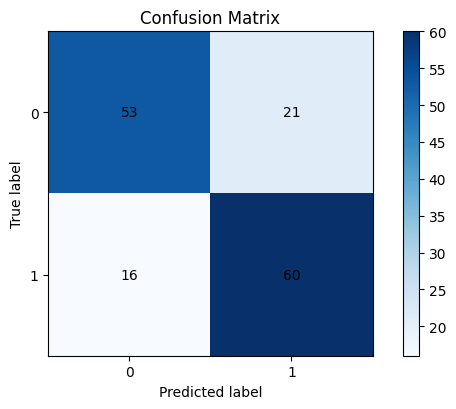


===== Top 2 Setting =====
Learning Rate = 0.1
Regularization Lambda = 4.0
5-Fold CV Average Accuracy = 0.7400
Model Evaluation
Accuracy  : 0.7600
Precision : 0.7381
Recall    : 0.8158
F1-score  : 0.7750


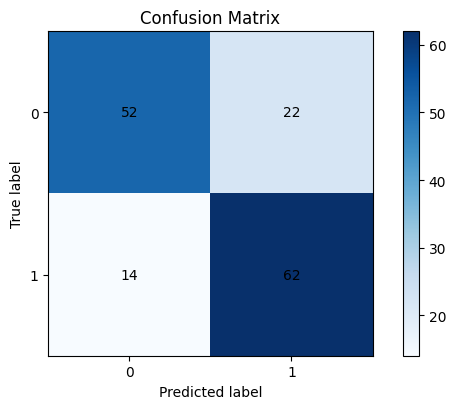

In [12]:
from model.metrics import evaluate_binary_classifier
# 用前兩組參數重新訓練，並在 testing data 上評估
for i, ((reg_lambda, lr), cv_acc) in enumerate(top2.items(), start=1):

    print(f"\n===== Top {i} Setting =====")
    print(f"Learning Rate = {lr}")
    print(f"Regularization Lambda = {reg_lambda}")
    print(f"5-Fold CV Average Accuracy = {cv_acc:.4f}")

    model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=loss_fn,
        act_fn=act_fn,
        grad_fn=grad_fn,
        lr=lr,
        reg_type='l2',
        reg_lambda=reg_lambda,
        n_iteration=10000,
        val_ratio=0,
        random_state=seed,
        verbose=False,
        plot_curve=False
    )

    # train on full training data
    model.fit(X_train, y_train)

    # predict on testing data
    y_pred = model.predict(X_test)

    # evaluate
    evaluate_binary_classifier(y_test, y_pred)